# 3. Two stars, one light curve — why photometry alone can't map spots

Light-curve inversion is famously ill-posed: very different spot maps can
produce *exactly* the same light curve. The paper's central result is that
astrometry sees precisely the surface structure photometry is blind to —
so the two together can map what neither can alone.

Let's make the degeneracy concrete before touching any math.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


## Build two visibly different stars with identical light curves

Starting from a spotted star, we add surface structure drawn purely from
the *photometric null space* (odd spherical-harmonic degrees $\ge 3$).
The second star looks clearly different — but its light curve is
unchanged to machine precision, at every rotation phase:

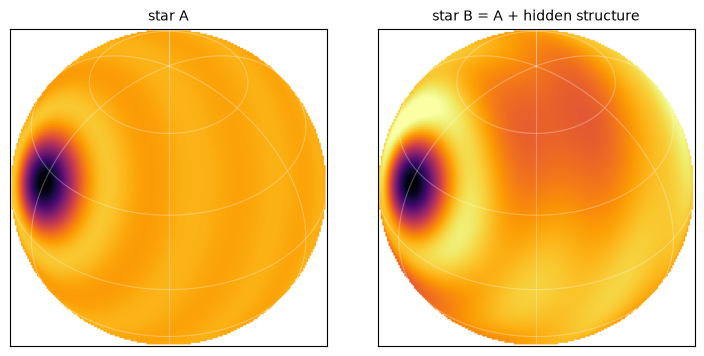

In [2]:
L, N = 10, 150
times = np.linspace(0, 2*np.pi, N, endpoint=False)
fm = jm.ForwardModel(times, l_max=L)
sh = jm.SHIndexer(L)

star_a = jm.multispot_surface([(25, 300, 14.0)], L)

# structure invisible to photometry: odd degree-3 modes
hidden = np.zeros(sh.total_coeffs, dtype=complex)
hidden[sh.get_index(3, 0)] = -0.20
hidden[sh.get_index(3, 2)] = -0.13 + 0.10j
hidden[sh.get_index(3, -2)] = np.conj(hidden[sh.get_index(3, 2)])
hidden[sh.get_index(3, 1)] = 0.10 - 0.07j
hidden[sh.get_index(3, -1)] = -np.conj(hidden[sh.get_index(3, 1)])
star_b = star_a + hidden

beta = 0.7
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
show_star(axes[0], star_a, L, beta, "star A")
show_star(axes[1], star_b, L, beta, "star B = A + hidden structure")
plt.tight_layout()

max light-curve difference : 0.0
max astrometric difference : 0.053029734798377144


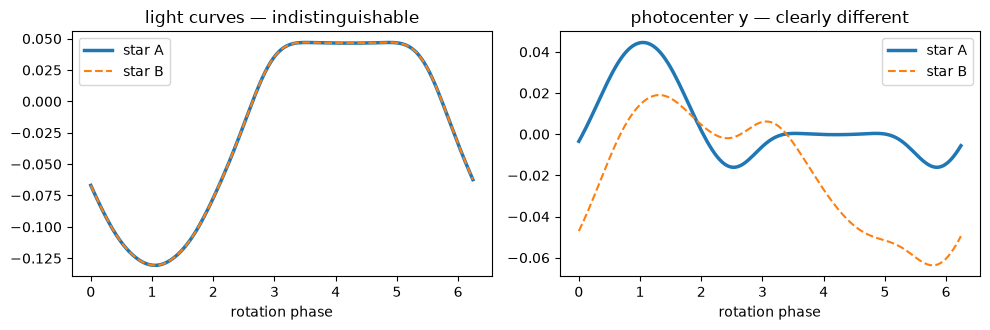

In [3]:
ya = fm.observe(star_a, beta, channels="xyp", stacked=False)
yb = fm.observe(star_b, beta, channels="xyp", stacked=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(times, ya["p"], lw=2.5, label="star A")
axes[0].plot(times, yb["p"], "--", lw=1.5, label="star B")
axes[0].set_title("light curves — indistinguishable"); axes[0].legend()
axes[1].plot(times, ya["y"], lw=2.5, label="star A")
axes[1].plot(times, yb["y"], "--", lw=1.5, label="star B")
axes[1].set_title("photocenter y — clearly different"); axes[1].legend()
for ax in axes: ax.set_xlabel("rotation phase")
plt.tight_layout()

print("max light-curve difference :", np.abs(yb['p'] - ya['p']).max())
print("max astrometric difference :", max(np.abs(yb['x'] - ya['x']).max(),
                                          np.abs(yb['y'] - ya['y']).max()))

A photometric survey could never tell these stars apart; a single
astrometric channel separates them immediately.

## Why: the sensitivity maps of the two techniques

Each observable responds to each harmonic $(l, m)$ through a kernel — its
"sensitivity map" over the surface modes. Plotting the kernel magnitudes
reveals a strict parity split (paper Section 2.2):

* **photometry** responds to **even** degrees (symmetric about the
  equator), plus $l \le 2$;
* **astrometry** responds to **odd** degrees (anti-symmetric about the
  equator), plus $l \le 2$.

Intuitively, the photocenter is an *asymmetric* position average over the
disk — a perfectly equator-symmetric pattern cannot shift it.

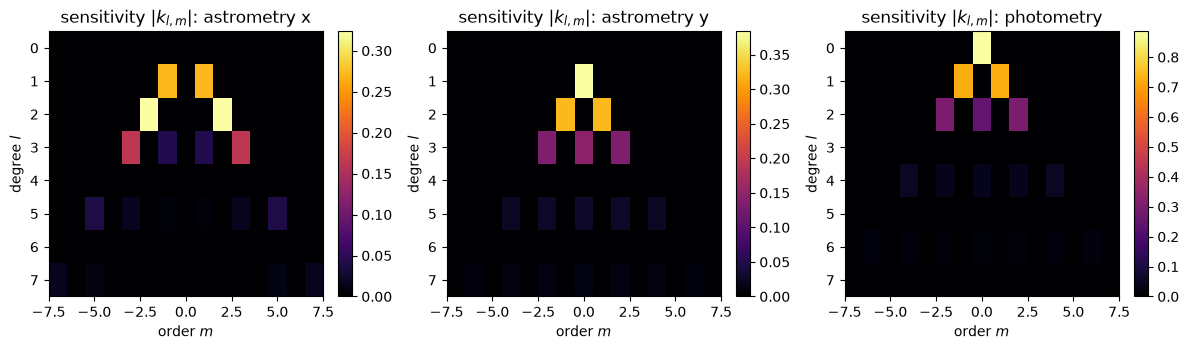

In [4]:
from jittermap.forward.kernels import compute_A_lm, compute_A_lm_photo

L7 = 7
A_x, A_y = compute_A_lm(L7)
A_p = compute_A_lm_photo(L7)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, A, title in zip(axes, [A_x, A_y, A_p],
                        ["astrometry x", "astrometry y", "photometry"]):
    im = ax.imshow(np.abs(A), cmap="inferno", aspect="auto",
                   extent=[-L7-0.5, L7+0.5, L7+0.5, -0.5])
    ax.set_title(f"sensitivity $|k_{{l,m}}|$: {title}")
    ax.set_xlabel("order $m$"); ax.set_ylabel("degree $l$")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

Dark rows are blind spots: photometry's blind rows (odd $l \ge 3$) are
exactly where the "hidden structure" above lived, and they are bright rows
for astrometry. Together the two cover **every** degree — the formal basis
for joint mapping. (Astrometry has its own blind rows at even
$l \ge 4$, which photometry fills in — the complementarity goes both
ways.)